# Løsningsforslag med beregninger

Beregninger til oppgavene 20.6, 20.7, 20.9, 23.1–23.4, samt eksamensoppgavene fra H23 og H24.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt


pd.set_option("display.width", 120)
np.set_printoptions(precision=4, suppress=True)

## Oppgave 20.6

In [ ]:
x = np.array([1, 3, 7])
y = np.array([1, 2, 4])

beta1 = (y[1] - y[0]) / (x[1] - x[0])
beta1_check = (y[2] - y[1]) / (x[2] - x[1])
beta0 = y[0] - beta1 * x[0]
print("Stigning (mellom pkt 1-2):", beta1)
print("Stigning (mellom pkt 2-3):", beta1_check)
print(f"Regresjonslinje: y = {beta0} + {beta1}*x")

pred_olaug = beta0 + beta1 * 5
print("Anslag for Olaug (x=5):", pred_olaug)

r = np.corrcoef(x, y)[0, 1]
print("r =", r)

Stigning (mellom pkt 1-2): 0.5
Stigning (mellom pkt 2-3): 0.5
Regresjonslinje: y = 0.5 + 0.5*x
Anslag for Olaug (x=5): 3.0
r = 1.0


## Oppgave 20.7

In [ ]:
xa = np.array([50, 60, 70]); ya = np.array([1, 2, 3])
ra = np.corrcoef(xa, ya)[0, 1]
print("a. r =", ra)

xb = np.array([2, -1, 4, 2, 6]); yb = np.array([1, 13, 0, 0, 1])
rb = np.corrcoef(xb, yb)[0, 1]
print("b. r =", rb)

xc = np.array([2, 9, 9, 3, 7, 9, -8, 7, -6, 0, 8, -2, -1])
yc = np.array([-1, -4, -3, 1, 0, 8, -2, 7, 1, 2, 10, 4, -4])
print("c. n =", len(xc), len(yc))
rc = np.corrcoef(xc, yc)[0, 1]
print("c. r =", rc)

a. r = 1.0
b. r = -0.7515933898832221
c. n = 13 13
c. r = 0.27956812160903877


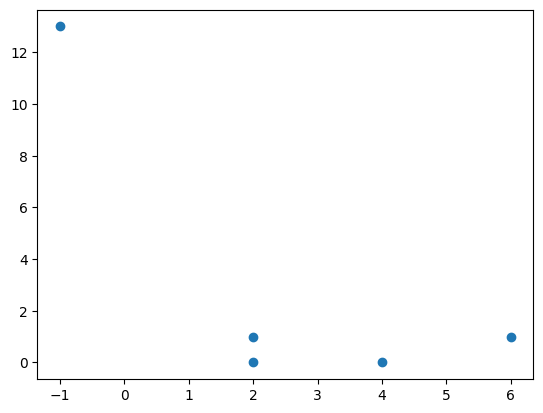

In [ ]:
plt.scatter(xb, yb)

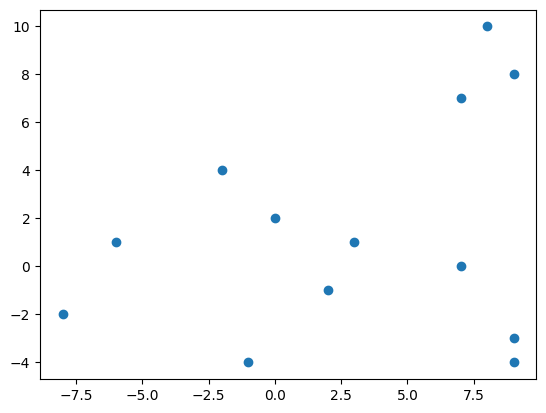

In [ ]:
plt.scatter(xc, yc)

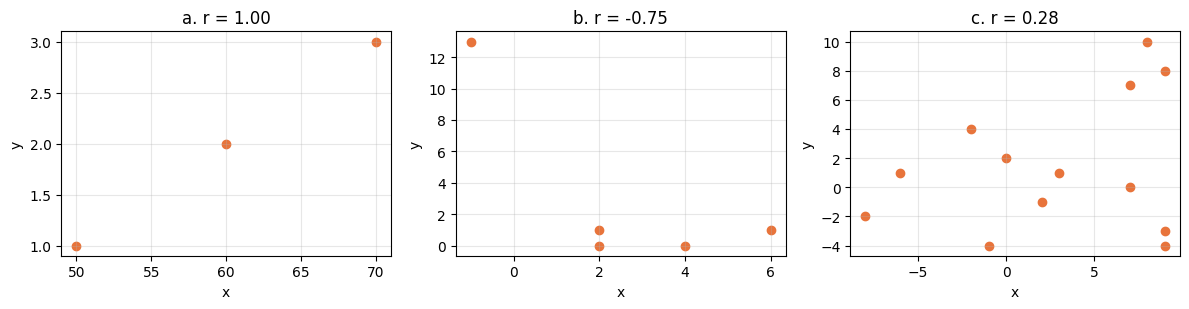

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, (xx, yy, lbl, rr) in zip(
    axs,
    [(xa, ya, "a", ra), (xb, yb, "b", rb), (xc, yc, "c", rc)],
):
    ax.scatter(xx, yy, color="#E8743B")
    ax.set_title(f"{lbl}. r = {rr:.2f}")
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Oppgave 20.9

In [ ]:
r = 0.63
sx, sy = 1.68, 1.88
xbar, ybar = 7.90, 7.81

beta1 = r * (sy / sx)
beta0 = ybar - beta1 * xbar
print("beta1_hat =", beta1)
print("beta0_hat =", beta0)

pred = beta0 + beta1 * 5
print("Prediksjon for digitfornoyd=5:", pred)

R2 = r ** 2
print("R^2 =", R2)

beta1_hat = 0.7050000000000001
beta0_hat = 2.240499999999999
Prediksjon for digitfornoyd=5: 5.765499999999999
R^2 = 0.39690000000000003


## Oppgave 23.1

In [ ]:
# a-c: lite utvalg (n=48)
tab_small = np.array([[11, 1, 8], [18, 3, 7]])  # rader: Mann, Kvinne; kolonner: Aldri, Bare pa fest, Oftere
rowsum = tab_small.sum(axis=1); colsum = tab_small.sum(axis=0); n = tab_small.sum()
print("Radsummer:", rowsum, " Kolonnesummer:", colsum, " n =", n)

E_small = np.outer(rowsum, colsum) / n
print("Forventet antall E:\n", E_small)
print("Antall celler med E<5:", (E_small < 5).sum(), "av", E_small.size)

Radsummer: [20 28]  Kolonnesummer: [29  4 15]  n = 48
Forventet antall E:
 [[12.0833  1.6667  6.25  ]
 [16.9167  2.3333  8.75  ]]
Antall celler med E<5: 2 av 6


In [ ]:
# d-g: stort utvalg
tab_large = np.array([[350, 72, 263], [469, 97, 220]])
rowsum2 = tab_large.sum(axis=1); colsum2 = tab_large.sum(axis=0); n2 = tab_large.sum()
print("Radsummer:", rowsum2, " Kolonnesummer:", colsum2, " n =", n2)

pct_kvinner_aldri = tab_large[1, 0] / n2 * 100
print("Andel kvinner som aldri snuser (av hele utvalget):", round(pct_kvinner_aldri, 2), "%")

chi2, p, dof, E_large = stats.chi2_contingency(tab_large, correction=False)
print("chi2 =", chi2, " p =", p, " df =", dof)
print("Forventet antall:\n", E_large)

crit = stats.chi2.ppf(0.95, dof)
print("Kritisk verdi (alpha=0.05):", crit)
print("Konklusjon:", "forkast H0" if chi2 > crit else "behold H0")

Radsummer: [685 786]  Kolonnesummer: [819 169 483]  n = 1471
Andel kvinner som aldri snuser (av hele utvalget): 31.88 %
chi2 = 17.966943818843454  p = 0.0001254664821679978  df = 2
Forventet antall:
 [[381.3834  78.6982 224.9184]
 [437.6166  90.3018 258.0816]]
Kritisk verdi (alpha=0.05): 5.991464547107979
Konklusjon: forkast H0


## Oppgave 23.2

In [ ]:
tab = np.array([[16, 28, 18, 7], [7, 20, 10, 11]])  # Mann, Kvinne x Audi, Ford, Mercedes, Volvo
rowsum = tab.sum(axis=1); colsum = tab.sum(axis=0); n = tab.sum()
print("Radsummer:", rowsum, " Kolonnesummer:", colsum, " n =", n)
print("Andel Ford:", round(colsum[1] / n * 100, 2), "%")

chi2, p, dof, E = stats.chi2_contingency(tab, correction=False)
print("Forventet antall:\n", E)
print("chi2 =", chi2, " p =", p, " df =", dof)

crit = stats.chi2.ppf(0.95, dof)
print("Kritisk verdi:", crit)
print("Konklusjon:", "forkast H0" if chi2 > crit else "behold H0")

Radsummer: [69 48]  Kolonnesummer: [23 48 28 18]  n = 117
Andel Ford: 41.03 %
Forventet antall:
 [[13.5641 28.3077 16.5128 10.6154]
 [ 9.4359 19.6923 11.4872  7.3846]]
chi2 = 4.402266743181204  p = 0.2211752994581237  df = 3
Kritisk verdi: 7.814727903251179
Konklusjon: behold H0


## Oppgave 23.3

In [ ]:
tab = np.array([[271, 1477, 3102], [33, 116, 167]])  # ja, nei x Ungdomsskole, Videregaende, Hoyere
rowsum = tab.sum(axis=1); colsum = tab.sum(axis=0); n = tab.sum()
print("Radsummer:", rowsum, " Kolonnesummer:", colsum, " n =", n)

chi2, p, dof, E = stats.chi2_contingency(tab, correction=False)
print("Forventet antall:\n", E)
print("Minste forventede verdi:", E.min())
print("chi2 =", chi2, " p =", p, " df =", dof)

crit = stats.chi2.ppf(0.95, dof)
print("Kritisk verdi:", crit)
print("Konklusjon:", "forkast H0" if chi2 > crit else "behold H0")

Radsummer: [4850  316]  Kolonnesummer: [ 304 1593 3269]  n = 5166
Forventet antall:
 [[ 285.4046 1495.5575 3069.0379]
 [  18.5954   97.4425  199.9621]]
Minste forventede verdi: 18.5954316686024
chi2 = 21.437207906732006  p = 2.2129390338744428e-05  df = 2
Kritisk verdi: 5.991464547107979
Konklusjon: forkast H0


## Oppgave 23.4

In [ ]:
tab = np.array([[15, 20], [30, 20], [5, 10]])  # A-, B-, C-vare x Maskin1, Maskin2
rowsum = tab.sum(axis=1); colsum = tab.sum(axis=0); n = tab.sum()
print("Radsummer:", rowsum, " Kolonnesummer:", colsum, " n =", n)

chi2, p, dof, E = stats.chi2_contingency(tab, correction=False)
print("Forventet antall:\n", E)
print("chi2 =", chi2, " p =", p, " df =", dof)

crit = stats.chi2.ppf(0.95, dof)
print("Kritisk verdi:", crit)
print("Konklusjon:", "forkast H0" if chi2 > crit else "behold H0")

Radsummer: [35 50 15]  Kolonnesummer: [50 50]  n = 100
Forventet antall:
 [[17.5 17.5]
 [25.  25. ]
 [ 7.5  7.5]]
chi2 = 4.380952380952381  p = 0.11186346761447095  df = 2
Kritisk verdi: 5.991464547107979
Konklusjon: behold H0


## Eksamensoppgaver --- innlasting av data

`Datasett_eksamen_h23.csv` brukes for "H24, sek. 8.2" og "H24, sek. 3.2" (til tross for "H24"
i oppgavenavnet, bekreftet ved at de beregnede testverdiene stemmer eksakt med de oppgitte
SPSS-verdiene og svaralternativene). `Datasett_til_eksamen_h-24.csv` brukes for "H24, sek. 3.1
og 3.2" (som eksplisitt nevner datasettnavnet i oppgaveteksten).

In [ ]:
url = 'https://raw.githubusercontent.com/uit-bed-2501/uit-bed-2501/main/data/Datasett_eksamen_h23.csv'
h23 = pd.read_csv(url, sep=";")
h23.head()

,Kjonn,Alder,Landsdel,Opptak,Kartlegging,Forkurs,Studietid,Jobbtid,Bachelor,Master
0,1,23,5,"4,24","74,47","78,57","25,39","14,43","3,05",3
1,0,20,1,"2,66","25,43","79,26","24,55","18,26","2,4",4
2,0,21,1,"3,64","89,52","94,95","28,73","19,28","3,46",2
3,1,20,5,"5,59","82,28","70,88","30,88",0,"3,33",4
4,0,25,5,"2,77","57,63","59,86","27,06","7,61","3,3",3


In [4]:
url = 'https://raw.githubusercontent.com/uit-bed-2501/uit-bed-2501/main/data/Datasett_eksamen_h24.csv'
h24 = pd.read_csv(url, sep=";")
h24.head()

,Kjonn,Alder,Treningstid,Inntekt,Matbudsjett,Antall,Hobby
0,1,26,5,573705,5527,1,3
1,2,41,0,814428,5742,2,1
2,2,51,3,1107420,12894,3,4
3,1,33,2,1010615,8270,3,4
4,2,27,1,429147,5868,1,1


In [ ]:

h23 = pd.read_csv("Datasett_eksamen_h23.csv", sep=";", decimal=",")
h24 = pd.read_csv("Datasett_til_eksamen_h-24.csv", sep=";")
print(h23.shape, h23.columns.tolist())
print(h24.shape, h24.columns.tolist())

(230, 10) ['Kjonn', 'Alder', 'Landsdel', 'Opptak', 'Kartlegging', 'Forkurs', 'Studietid', 'Jobbtid', 'Bachelor', 'Master']
(250, 7) ['Kjonn', 'Alder', 'Treningstid', 'Inntekt', 'Matbudsjett', 'Antall', 'Hobby']


## H24, sek. 8.2,Lukket --- Levene's test, Jobbtid ~ Landsdel (bruker h23-datasettet)

In [ ]:
groups = [g["Jobbtid"].values for _, g in h23.groupby("Landsdel")]
print("Antall landsdeler (grupper):", len(groups), " Gruppestørrelser:", [len(g) for g in groups])

W, p = stats.levene(*groups, center="mean")
print("Levene statistic =", W, " p =", p)
print("(Sammenlign med oppgitt SPSS-tabell: .059 / .993 -- stemmer.)")

Antall landsdeler (grupper): 5  Gruppestørrelser: [46, 14, 57, 9, 104]
Levene statistic = 0.05921531431687384  p = 0.9934682071943728
(Sammenlign med oppgitt SPSS-tabell: .059 / .993 -- stemmer.)


## H24, sek. 9.2, Lukket --- multippel regresjon boligpris (ingen rådata gitt)

Denne oppgaven har ingen vedlagt datasett -- vi besvarer den direkte fra den oppgitte
SPSS-utskriften (ANOVA- og koeffisienttabellen).

In [ ]:
beta_sol = 36104.361
print("3 ekstra soltimer, alt annet likt: pris opp med", 3 * beta_sol, "kr")

beta_areal_std = 0.562
print("Areal opp 1 standardavvik -> pris opp", beta_areal_std, "standardavvik")

betas = {"Areal": .562, "Tilstand": .291, "Alder": -.845, "Sentrum": -.070, "Sol": .059}
mest_betydning = max(betas, key=lambda k: abs(betas[k]))
print("Størst betydning (størst |Beta|):", mest_betydning, betas[mest_betydning])

sig = {"Areal": 1e-4, "Tilstand": 1e-4, "Alder": 1e-4, "Sentrum": .120, "Sol": .192}
minst_signifikant = max(sig, key=sig.get)
print("Minst signifikant (høyest Sig.):", minst_signifikant, sig[minst_signifikant])

3 ekstra soltimer, alt annet likt: pris opp med 108313.08299999998 kr
Areal opp 1 standardavvik -> pris opp 0.562 standardavvik
Størst betydning (størst |Beta|): Alder -0.845
Minst signifikant (høyest Sig.): Sol 0.192


## H24, sek. 3.1 og 3.2, Åpen --- fem delspørsmål (bruker h24-datasettet)

### (1) ANOVA: Inntekt ~ Hobby

In [ ]:
groups = [g["Inntekt"].values for _, g in h24.groupby("Hobby")]
F, p = stats.f_oneway(*groups)
grand = h24["Inntekt"].mean()
ssb = sum(len(g) * (g.mean() - grand) ** 2 for g in groups)
sst = sum((h24["Inntekt"] - grand) ** 2)
eta2 = ssb / sst
print("F =", F, " p =", p, " eta^2 =", eta2)
print(h24.groupby("Hobby")["Inntekt"].agg(["mean", "count"]))

F = 92.20743798140069  p = 5.1289365873255084e-40  eta^2 = 0.5292967915138346
                mean  count
Hobby                      
1      699974.521739     69
2      663285.689655     58
3      678101.212766     47
4      963092.723684     76


### (2) Levene's test: Inntekt ~ Hobby

In [ ]:
W, p = stats.levene(*groups, center="mean")
print("Levene statistic =", W, " p =", p)

Levene statistic = 3.841065962713502  p = 0.010284215165595531


### (3) Énutvalgs t-test: urtedyrkere (Hobby=4) vs. 680 000 kr

In [ ]:
urte = h24.loc[h24["Hobby"] == 4, "Inntekt"]
n_u, mean_u, sd_u = len(urte), urte.mean(), urte.std(ddof=1)
print("n =", n_u, " gjennomsnitt =", mean_u, " std.avvik =", sd_u)

t_stat, p_val = stats.ttest_1samp(urte, 680000)
print("t =", t_stat, " p (tosidig) =", p_val)

se = sd_u / np.sqrt(n_u)
diff = mean_u - 680000
tcrit = stats.t.ppf(0.975, n_u - 1)
ci = (diff - tcrit * se, diff + tcrit * se)
print("Differanse =", diff, " 95% KI for differansen =", ci)

n = 76  gjennomsnitt = 963092.7236842106  std.avvik = 153500.73011940139
t = 16.077742082807095  p (tosidig) = 5.195957089501676e-26
Differanse = 283092.72368421056  95% KI for differansen = (np.float64(248016.3042635543), np.float64(318169.14310486685))


### (4) Kjikvadrattest: Kjønn × Hobby

In [ ]:
ct = pd.crosstab(h24["Kjonn"], h24["Hobby"])
print(ct)

chi2, p, dof, E = stats.chi2_contingency(ct, correction=False)
print("chi2 =", chi2, " p =", p, " df =", dof)
E_df = pd.DataFrame(E, index=ct.index, columns=ct.columns)
print("Forventet antall:\n", E_df)
print("E(Mann=2, Banjo=1) =", E_df.loc[2, 1])

Hobby   1   2   3   4
Kjonn                
1      32  26  29  39
2      37  32  18  37
chi2 = 3.5943381974505137  p = 0.3087313081913662  df = 3
Forventet antall:
 Hobby       1       2       3       4
Kjonn                                
1      34.776  29.232  23.688  38.304
2      34.224  28.768  23.312  37.696
E(Mann=2, Banjo=1) = 34.224


### (5) Toutvalgs t-test (lik varians): Treningstid, Kvinne vs. Mann

In [ ]:
g1 = h24.loc[h24["Kjonn"] == 1, "Treningstid"]  # Kvinne
g2 = h24.loc[h24["Kjonn"] == 2, "Treningstid"]  # Mann
t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=True)
print("n1 =", len(g1), " mean1 =", g1.mean(), " sd1 =", g1.std(ddof=1))
print("n2 =", len(g2), " mean2 =", g2.mean(), " sd2 =", g2.std(ddof=1))
print("t =", t_stat, " p =", p_val)

sp = np.sqrt(((len(g1) - 1) * g1.var(ddof=1) + (len(g2) - 1) * g2.var(ddof=1)) / (len(g1) + len(g2) - 2))
d = abs(g1.mean() - g2.mean()) / sp
print("Pooled std.avvik =", sp, " Cohen's d =", d)

n1 = 126  mean1 = 3.015873015873016  sd1 = 1.584848898711177
n2 = 124  mean2 = 3.120967741935484  sd2 = 1.347039765200812
t = -0.5645255111264724  p = 0.5729067696361467
Pooled std.avvik = 1.4717141336846582  Cohen's d = 0.07140974164551078


## H24, sek. 3.2 --- ANOVA: Bachelor ~ Landsdel (bruker h23-datasettet)

In [ ]:
groups = [g["Bachelor"].values for _, g in h23.groupby("Landsdel")]
F, p = stats.f_oneway(*groups)
grand = h23["Bachelor"].mean()
ssb = sum(len(g) * (g.mean() - grand) ** 2 for g in groups)
sst = sum((h23["Bachelor"] - grand) ** 2)
eta2 = ssb / sst
print("F =", F, " p =", p, " eta^2 =", eta2)
print("(Sammenlign med de oppgitte svaralternativene: 1.565 og 0.027 -- stemmer.)")

F = 1.565493597237049  p = 0.18444026546367323  eta^2 = 0.02707740606943224
(Sammenlign med de oppgitte svaralternativene: 1.565 og 0.027 -- stemmer.)


## H23, sek. 7.3, Lukket --- ANOVA for CRIM (ingen rådata gitt)

In [ ]:
SSB, dfB = 14958.715, 8
SSW, dfW = 22404.506, 497
MSB, MSW = SSB / dfB, SSW / dfW
F = MSB / MSW
print("Antall grupper =", dfB + 1)
print("MSB =", MSB, " MSW =", MSW, " F =", F)

Antall grupper = 9
MSB = 1869.839375  MSW = 45.07948893360161  F = 41.478717244423954


## H23, sek. 8.2, Lukket --- Levene's test for Vekt (ingen rådata gitt)

Gitt SPSS-utskrift: Levene-statistikk $=0.792$, $df_1=3$, $df_2=86$, Sig.$=.502$ (basert på
gjennomsnitt). Siden $p=.502>0.05$ beholder vi $H_0$ (lik varians i alle 4 gruppene) --- ingen
egen Python-beregning er nødvendig, kun tolkning av den oppgitte $p$-verdien.